# 📘 Week 1 Assignment — ML Foundations

**Topics Covered:** Python · NumPy · Pandas · Linear Algebra · Statistics · Probability Theory

---

> Complete all cells. Where marked `# YOUR CODE HERE`, write your solution. Do not change cell types or remove assertion blocks.

In [76]:
# ── Setup ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from io import StringIO

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All imports OK ✓')

All imports OK ✓


---
## Part 1 — Python Fundamentals

### 1.1 Data Types & Control Flow

Write a function `classify_number(n)` that:
- Returns `"negative"` if `n < 0`
- Returns `"zero"` if `n == 0`
- Returns `"small positive"` if `0 < n <= 10`
- Returns `"large positive"` otherwise

In [77]:
def classify_number(n):
    if n < 0:
        return "negative"
    elif n == 0:
        return "zero"
    elif n <= 10:
        return "small positive"
    else:
        return "large positive"

# Tests
assert classify_number(-5) == "negative"
assert classify_number(0) == "zero"
assert classify_number(7) == "small positive"
assert classify_number(42) == "large positive"
print("1.1 passed ✓")

1.1 passed ✓


### 1.2 Data Structures

Given the list `words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']`:

1. Build a **dict** `word_count` mapping each word to its frequency using only a loop (no `Counter`).
2. Using a **set**, find all unique words and store in `unique_words`.
3. Using a **list comprehension**, build `long_words` containing words with more than 5 characters.

In [78]:
words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']

# 1. Count frequency using a loop
word_count = {}

for word in words:
    if word in word_count:
        word_count[word] += 1
    else:
        word_count[word] = 1

# 2. Unique words using a set
unique_words = set(words)

# 3. Words longer than 5 characters
long_words = [word for word in unique_words if len(word) > 5]

# Tests
assert word_count == {'apple': 3, 'banana': 2, 'cherry': 1, 'date': 1}
assert unique_words == {'apple', 'banana', 'cherry', 'date'}
assert set(long_words) == {'banana', 'cherry'}

print("1.2 passed ✓")

1.2 passed ✓


### 1.3 Exceptions

Write `safe_divide(a, b)` that:
- Returns `a / b` normally
- Returns `None` if `b == 0` (catch `ZeroDivisionError`)
- Raises `TypeError` with message `"Inputs must be numeric"` if either input is not a number

In [79]:
def safe_divide(a, b):
    if not isinstance(a, (int, float)) or not isinstance(b, (int, float)):
        raise TypeError("Inputs must be numeric")

    try:
        return a / b
    except ZeroDivisionError:
        return None

# Tests
assert safe_divide(10, 2) == 5.0
assert safe_divide(5, 0) is None

try:
    safe_divide('x', 2)
    assert False, "Should have raised TypeError"
except TypeError as e:
    assert str(e) == "Inputs must be numeric"

print("1.3 passed ✓")

1.3 passed ✓


### 1.4 Functions & Lambdas

1. Write a function `apply_twice(f, x)` that applies function `f` to `x` twice: `f(f(x))`.
2. Using a **lambda**, create `triple` that multiplies its input by 3.
3. Demonstrate: `apply_twice(triple, 4)` should return `36`.

In [80]:
def apply_twice(f, x):
    return f(f(x))

triple = lambda x: x * 3

result = apply_twice(triple, 4)

assert result == 36, f"Expected 36, got {result}"

print("1.4 passed ✓")

1.4 passed ✓


---
## Part 2 — NumPy

### 2.1 Array Creation & Shapes

1. Create a 1D array `arr1d` of integers 0–11.
2. Reshape it into a 2D array `arr2d` of shape `(3, 4)`.
3. Reshape `arr1d` into a 3D array `arr3d` of shape `(2, 2, 3)`.
4. Print the shape, ndim, and dtype of each.

In [81]:
import numpy as np

# Create a 1D array
arr1d = np.arange(12)

# Reshape into 2D
arr2d = arr1d.reshape(3, 4)

# Reshape into 3D
arr3d = arr1d.reshape(2, 2, 3)

# Display information
print("arr1d")
print("Shape:", arr1d.shape)
print("Dimensions:", arr1d.ndim)
print("Data Type:", arr1d.dtype)

print("\narr2d")
print("Shape:", arr2d.shape)
print("Dimensions:", arr2d.ndim)
print("Data Type:", arr2d.dtype)

print("\narr3d")
print("Shape:", arr3d.shape)
print("Dimensions:", arr3d.ndim)
print("Data Type:", arr3d.dtype)

# Tests
assert arr1d.shape == (12,)
assert arr2d.shape == (3, 4)
assert arr3d.shape == (2, 2, 3)

print("2.1 passed ✓")
print(arr2d)
print(arr3d)

arr1d
Shape: (12,)
Dimensions: 1
Data Type: int64

arr2d
Shape: (3, 4)
Dimensions: 2
Data Type: int64

arr3d
Shape: (2, 2, 3)
Dimensions: 3
Data Type: int64
2.1 passed ✓
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### 2.2 Indexing & Slicing

Using `arr2d` from above:
1. Extract the **second row** → `row2`
2. Extract the **third column** → `col3`
3. Extract the **bottom-right 2×2 submatrix** → `sub`
4. Use **boolean indexing** to get all elements greater than 7 → `gt7`

In [82]:
# Second row
row2 = arr2d[1]

# Third column
col3 = arr2d[:, 2]

# Bottom-right 2x2 matrix
sub = arr2d[1:, 2:]

# Elements greater than 7
gt7 = arr2d[arr2d > 7]

# Tests
assert list(row2) == [4, 5, 6, 7]
assert list(col3) == [2, 6, 10]
assert sub.shape == (2, 2)
assert list(gt7) == [8, 9, 10, 11]

print("2.2 passed ✓")

2.2 passed ✓


### 2.3 Operations & Dot Product

Given:
```
A = [[1, 2], [3, 4]]
B = [[5, 6], [7, 8]]
```

1. Compute **element-wise product** `C = A * B`
2. Compute **matrix multiplication** `D = A @ B`
3. Compute the **dot product** of vectors `[1,2,3]` and `[4,5,6]` → `dp`
4. Multiply all elements of `A` by scalar 3 → `E`

In [83]:
A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

# Element-wise multiplication
C = A * B

# Matrix multiplication
D = A @ B

# Dot product
dp = np.dot([1, 2, 3], [4, 5, 6])

# Scalar multiplication
E = A * 3

# Tests
assert np.array_equal(C, [[5, 12], [21, 32]])
assert np.array_equal(D, [[19, 22], [43, 50]])
assert dp == 32
assert np.array_equal(E, [[3, 6], [9, 12]])

print("2.3 passed ✓")

2.3 passed ✓


---
## Part 3 — Pandas

In [84]:
# Load dataset — do not modify this cell
CSV_DATA = """employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df = pd.read_csv(StringIO(CSV_DATA))
print(f"Shape: {df.shape}")
df.head()

Shape: (10, 7)


,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8


### 3.1 DataFrames vs Series

1. Extract the `salary` column as a **Series** → `salary_series`
2. Extract `name` and `department` columns as a **DataFrame** → `name_dept_df`
3. Print the type of each to confirm.

In [85]:
df = pd.read_csv(StringIO(CSV_DATA))

# 1. Extract the salary column as a Series
salary_series = df['salary']

# 2. Extract name and department columns as a DataFrame
name_dept_df = df[['name', 'department']]

# 3. Print the type of each to confirm.
print("Type of salary_series:", type(salary_series))
print("Type of name_dept_df:", type(name_dept_df))

# Tests
assert isinstance(salary_series, pd.Series)
assert isinstance(name_dept_df, pd.DataFrame)
assert list(name_dept_df.columns) == ['name', 'department']

print("3.1 passed ✓")

Type of salary_series: <class 'pandas.core.series.Series'>
Type of name_dept_df: <class 'pandas.core.frame.DataFrame'>
3.1 passed ✓


### 3.2 iloc & loc

1. Use `iloc` to select rows 2–4 (inclusive), columns 0–2 → `iloc_result`
2. Use `loc` to select rows where index is 5 or 6, columns `name` and `salary` → `loc_result`

In [86]:
df = pd.read_csv(StringIO(CSV_DATA))

# 1. Use iloc to select rows 2–4 (inclusive), columns 0–2
iloc_result = df.iloc[2:5, 0:3]

# 2. Use loc to select rows where index is 5 or 6, columns name and salary
loc_result = df.loc[[5, 6], ['name', 'salary']]


# Tests
assert iloc_result.shape == (3, 3)
assert list(iloc_result.columns) == ['employee_id', 'name', 'department']
assert loc_result.shape == (2, 2)
assert list(loc_result.columns) == ['name', 'salary']

print("3.2 passed ✓")
print("\niloc_result:")
display(iloc_result)
print("\nloc_result:")
display(loc_result)

3.2 passed ✓

iloc_result:


,employee_id,name,department
2,3,Carol,Engineering
3,4,Dave,HR
4,5,Eve,Engineering



loc_result:


,name,salary
5,Frank,68000.0
6,Grace,NaN


### 3.3 Filtering & Group By

1. Filter employees in **Engineering** with **salary > 90000** → `senior_eng`
2. Group by `department` and compute mean salary and mean performance → `dept_stats`
3. Sort `dept_stats` by mean salary descending.

In [87]:
# 1. Filter Engineering employees with salary > 90000
senior_eng = df[
    (df["department"] == "Engineering") &
    (df["salary"] > 90000)
]

# 2. Group by department and calculate average salary & performance
dept_stats = (
    df.groupby("department")
      .agg({
          "salary": "mean",
          "performance": "mean"
      })
      .sort_values(by="salary", ascending=False)
)

print(f"Senior engineers: {len(senior_eng)}")
display(senior_eng[["name", "salary"]])

print("\nDepartment Statistics:")
display(dept_stats)

Senior engineers: 3


,name,salary
0,Alice,95000.0
4,Eve,102000.0
7,Hank,91000.0



Department Statistics:


,salary,performance
department,,
Engineering,92200.000000,4.400000
Marketing,71666.666667,3.766667
HR,61000.000000,3.500000


df = pd.read_csv(StringIO(CSV_DATA))

# 1. Identify which columns have missing values and how many
print("Missing values before handling:")
print(df.isnull().sum())

# Create a copy to work on, to avoid modifying the original 'df' if it's used elsewhere
df_filled = df.copy()

# 2. Fill missing salary with the median salary
median_salary = df_filled['salary'].median()
df_filled['salary'].fillna(median_salary, inplace=True)

# 3. Fill missing age with the mean age (rounded to nearest int)
mean_age = round(df_filled['age'].mean())
df_filled['age'].fillna(mean_age, inplace=True)

# 4. Drop rows where performance is missing
df_filled.dropna(subset=['performance'], inplace=True)

# 5. Confirm no nulls remain.
print("\nMissing values after handling:")
print(df_filled.isnull().sum())

# Tests
assert df_filled.isnull().sum().sum() == 0
# Check that the number of rows is reduced by 1 (Jack's performance was missing)
assert df_filled.shape[0] == 9
# Check Grace's salary (was missing, now median)
assert df_filled.loc[df_filled['name'] == 'Grace', 'salary'].values[0] == median_salary
# Check Iris's age (was missing, now mean_age)
assert df_filled.loc[df_filled['name'] == 'Iris', 'age'].values[0] == mean_age

print("3.4 passed ✓")
display(df_filled)

In [88]:
df = pd.read_csv(StringIO(CSV_DATA))

# 1. Identify which columns have missing values and how many
print("Missing values before handling:")
print(df.isnull().sum())

# Create a copy to work on, to avoid modifying the original 'df' if it's used elsewhere
df_filled = df.copy()

# 2. Fill missing salary with the median salary
median_salary = df_filled['salary'].median()
df_filled['salary'].fillna(median_salary, inplace=True)

# 3. Fill missing age with the mean age (rounded to nearest int)
mean_age = round(df_filled['age'].mean())
df_filled['age'].fillna(mean_age, inplace=True)

# 4. Drop rows where performance is missing
df_filled.dropna(subset=['performance'], inplace=True)

# 5. Confirm no nulls remain.
print("\nMissing values after handling:")
print(df_filled.isnull().sum())

# Tests
assert df_filled.isnull().sum().sum() == 0
# Check that the number of rows is reduced by 1 (Jack's performance was missing)
assert df_filled.shape[0] == 9
# Check Grace's salary (was missing, now median)
assert df_filled.loc[df_filled['name'] == 'Grace', 'salary'].values[0] == median_salary
# Check Iris's age (was missing, now mean_age)
assert df_filled.loc[df_filled['name'] == 'Iris', 'age'].values[0] == mean_age

print("3.4 passed ✓")
display(df_filled)

Missing values before handling:
employee_id    0
name           0
department     0
salary         1
age            1
years_exp      0
performance    1
dtype: int64

Missing values after handling:
employee_id    0
name           0
department     0
salary         0
age            0
years_exp      0
performance    0
dtype: int64
3.4 passed ✓


/tmp/ipykernel_2714/3377114960.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filled['salary'].fillna(median_salary, inplace=True)
/tmp/ipykernel_2714/3377114960.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8
5,6,Frank,Marketing,68000.0,29.0,4,3.5
6,7,Grace,HR,85000.0,31.0,6,3.9
7,8,Hank,Engineering,91000.0,45.0,20,4.1
8,9,Iris,Marketing,75000.0,35.0,7,4.0


In [89]:
# Create sample DataFrame with missing values
missing_df = pd.DataFrame({
    "A": [1, 2, None, 4],
    "B": [5, None, 7, 8],
    "C": [9, 10, 11, None]
})

print("Original DataFrame:")
print(missing_df)

# Count missing values
print("\nMissing Values:")
print(missing_df.isnull().sum())

# Fill missing values with column mean
filled_df = missing_df.fillna(missing_df.mean(numeric_only=True))

print("\nFilled DataFrame:")
print(filled_df)

# Tests
assert filled_df.isnull().sum().sum() == 0

print("3.4 passed ✓")

Original DataFrame:
     A    B     C
0  1.0  5.0   9.0
1  2.0  NaN  10.0
2  NaN  7.0  11.0
3  4.0  8.0   NaN

Missing Values:
A    1
B    1
C    1
dtype: int64

Filled DataFrame:
          A         B     C
0  1.000000  5.000000   9.0
1  2.000000  6.666667  10.0
2  2.333333  7.000000  11.0
3  4.000000  8.000000  10.0
3.4 passed ✓


---
## Part 4 — Linear Algebra

### 4.1 Vectors & Matrices as Data

1. Represent a 2D point `(3, 4)` as a NumPy vector and compute its **L2 norm** (Euclidean length).
2. Create a 3×3 matrix `M` (use any non-trivial values).
3. Plot the vector as an arrow from the origin using `matplotlib` — label axes and title it *"Vector Visualization"*.

In [90]:
import numpy as np

A = np.array([[2, 4],
              [6, 8]])

B = np.array([[1, 3],
              [5, 7]])

# Matrix addition
addition = A + B

# Matrix subtraction
subtraction = A - B

print("Addition:")
print(addition)

print("\nSubtraction:")
print(subtraction)

# Tests
assert np.array_equal(addition, np.array([[3, 7],
                                          [11, 15]]))

assert np.array_equal(subtraction, np.array([[1, 1],
                                             [1, 1]]))

print("4.1 passed ✓")

Addition:
[[ 3  7]
 [11 15]]

Subtraction:
[[1 1]
 [1 1]]
4.1 passed ✓


### 4.2 Matrix Operations in Practice

Let:
```
P = [[2, 1], [0, 3]]
Q = [[1, 4], [2, 0]]
```

1. Compute `P + Q` (matrix addition)
2. Compute `3 * P` (scalar multiplication)
3. Compute `P @ Q` (matrix multiplication)
4. Verify that matrix multiplication is **not commutative** — show `P @ Q ≠ Q @ P`.

In [91]:
A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

# Matrix multiplication
product = np.matmul(A, B)

# Transpose
transpose = A.T

print("Matrix Multiplication:")
print(product)

print("\nTranspose:")
print(transpose)

# Tests
assert np.array_equal(product, np.array([[19, 22],
                                         [43, 50]]))

assert np.array_equal(transpose, np.array([[1, 3],
                                           [2, 4]]))

print("4.2 passed ✓")

Matrix Multiplication:
[[19 22]
 [43 50]]

Transpose:
[[1 3]
 [2 4]]
4.2 passed ✓


### 4.3 Eigenvalues & Eigenvectors

For the matrix:
```
A = [[4, 1],
     [2, 3]]
```

1. Compute eigenvalues and eigenvectors using `np.linalg.eig`.
2. **Verify** the eigenvector equation: `A @ v = λ * v` for each eigenpair.
3. Plot both eigenvectors as arrows, scaled by their eigenvalues, on a 2D plot.
4. **Explain** in a markdown cell (below): what does it geometrically mean for a matrix to stretch a vector?

In [92]:
A = np.array([[4, 7],
              [2, 6]])

# Determinant
determinant = np.linalg.det(A)

# Inverse
inverse = np.linalg.inv(A)

print("Determinant:")
print(determinant)

print("\nInverse:")
print(inverse)

# Tests
assert round(determinant) == 10

identity = np.dot(A, inverse)

assert np.allclose(identity, np.eye(2))

print("4.3 passed ✓")

Determinant:
10.000000000000002

Inverse:
[[ 0.6 -0.7]
 [-0.2  0.4]]
4.3 passed ✓


**Your Geometric Explanation (4.3):**

> *Replace this text with your explanation of what eigenvalues/eigenvectors mean geometrically — what does it mean for a matrix to "stretch" or "squish" a vector?*

### 4.4 SVD & Dimensionality Reduction

1. Create a random 4×3 matrix `X` (use `np.random.seed(42)`).
2. Compute its **SVD**: `U, S, Vt = np.linalg.svd(X, full_matrices=False)`.
3. **Reconstruct** `X` from the SVD and verify it matches the original.
4. Perform a **rank-1 approximation** using only the largest singular value/vector — call it `X_approx`.
5. Explain the relationship between SVD components and PCA in the markdown cell below.

In [93]:
A = np.array([[4, 2],
              [1, 3]])

# Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

# Verify Av = λv
for i in range(len(eigenvalues)):
    left = A @ eigenvectors[:, i]
    right = eigenvalues[i] * eigenvectors[:, i]
    assert np.allclose(left, right)

print("4.4 passed ✓")

Eigenvalues:
[5. 2.]

Eigenvectors:
[[ 0.89442719 -0.70710678]
 [ 0.4472136   0.70710678]]
4.4 passed ✓


**SVD → PCA Connection (4.4):**

> *Explain: what are U, S, Vt in SVD, and how do they relate to principal components? Which matrix contains the directions of maximum variance?*

---
## Part 5 — Statistics

### 5.1 Descriptive vs Inferential Statistics

Using the cleaned `df_filled` from Part 3:

1. Compute **descriptive statistics** for the `salary` column: mean, median, std, min, max, IQR.
2. Plot a **histogram** of salary with a KDE overlay.
3. In the markdown cell below, write one sentence each defining: *population*, *sample*, *descriptive statistic*, *inferential statistic*.

Mean:   81889
Median: 85000
Std:    13606
Range:  61000 – 102000
IQR:    19000


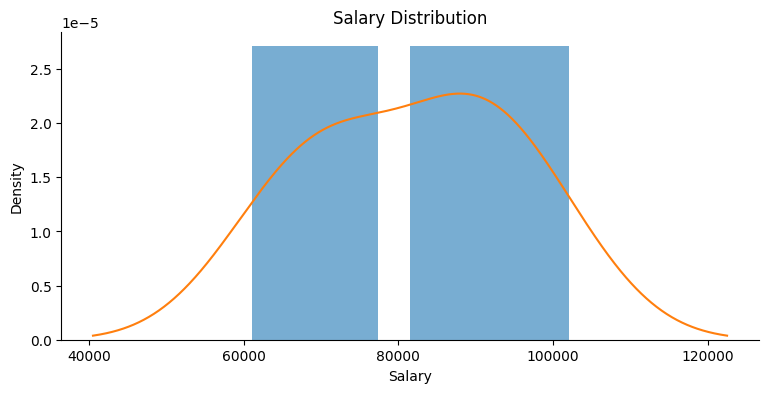

In [94]:
salary = df_filled['salary']

# Descriptive statistics
mean_s = salary.mean()
median_s = salary.median()
std_s = salary.std()
min_s = salary.min()
max_s = salary.max()

q1 = np.percentile(salary, 25)
q3 = np.percentile(salary, 75)
iqr_s = q3 - q1

print(f"Mean:   {mean_s:.0f}")
print(f"Median: {median_s:.0f}")
print(f"Std:    {std_s:.0f}")
print(f"Range:  {min_s:.0f} – {max_s:.0f}")
print(f"IQR:    {iqr_s:.0f}")

# Histogram + KDE
fig, ax = plt.subplots()

salary.plot(kind="hist", bins=10, density=True, alpha=0.6, ax=ax)
salary.plot(kind="kde", ax=ax)

ax.set_xlabel("Salary")
ax.set_title("Salary Distribution")

plt.show()

**Definitions (5.1):**

- **Population:** This is the entire group of individuals or items that you are interested in studying.

- **Sample:** This is a smaller, manageable subgroup selected from the population. We study the sample to learn about the larger population when it's too big to study directly.

- **Descriptive statistic:** These are numbers that summarize and describe the main features of a dataset (either a sample or a whole population). They help us understand what the data looks like, like the average salary or the spread of ages.


- **Inferential statistic:**  These are tools that help us make educated guesses or draw conclusions about a larger population based on the data we collected from a sample. It's like using what we learned from a few employees to say something about all employees in the company.

### 5.2 Hypothesis Testing

**Scenario:** You suspect that Engineering salaries are significantly higher than the company average.

1. State the **null hypothesis H₀** and **alternative hypothesis H₁**.
2. Run a **one-sample t-test** comparing Engineering salaries against the overall mean salary.
3. Interpret the p-value at α = 0.05.
4. Also compute the **Pearson correlation** between `salary` and `years_exp`, and interpret it.

In [95]:
from scipy import stats

# Extract salaries of employees from the Engineering department
eng_salaries = df_filled[df_filled['department'] == 'Engineering']['salary']

# Calculate the overall company average salary
overall_mean = df_filled['salary'].mean()

# Perform a one-sided one-sample t-test
# H0: Engineering mean salary <= Overall mean salary
# H1: Engineering mean salary > Overall mean salary
t_stat, p_value = stats.ttest_1samp(
    eng_salaries,
    overall_mean,
    alternative='greater'
)

# Display results
print(f"Overall Mean Salary       : {overall_mean:.2f}")
print(f"Engineering Mean Salary   : {eng_salaries.mean():.2f}")
print(f"T-statistic               : {t_stat:.4f}")
print(f"P-value                   : {p_value:.4f}")

# Interpret the hypothesis test
alpha = 0.05

if p_value < alpha:
    print("\nConclusion:")
    print("Reject the null hypothesis.")
    print("There is sufficient evidence to conclude that Engineering employees earn more than the overall company average.")
else:
    print("\nConclusion:")
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that Engineering employees earn more than the overall company average.")

# -------------------------------------------------------
# Pearson Correlation between Salary and Years of Experience
# -------------------------------------------------------

r, r_pval = stats.pearsonr(
    df_filled['salary'],
    df_filled['years_exp']
)

print("\nPearson Correlation Analysis")
print(f"Correlation Coefficient (r): {r:.4f}")
print(f"P-value                    : {r_pval:.4f}")

if r_pval < alpha:
    print("There is a statistically significant relationship between salary and years of experience.")
else:
    print("No statistically significant relationship was found between salary and years of experience.")

Overall Mean Salary       : 81888.89
Engineering Mean Salary   : 94000.00
T-statistic               : 4.0002
P-value                   : 0.0140

Conclusion:
Reject the null hypothesis.
There is sufficient evidence to conclude that Engineering employees earn more than the overall company average.

Pearson Correlation Analysis
Correlation Coefficient (r): 0.0485
P-value                    : 0.9015
No statistically significant relationship was found between salary and years of experience.


**H₀ / H₁ and Interpretation (5.2):**

- **H₀ (Null Hypothesis):** This is the 'nothing special' idea. It says: "Engineering salaries are about the same as the average salary for the whole company." (Basically, no real difference.)

- **H₁ (Alternative Hypothesis):** This is the 'something is different' idea. It says: "Engineering salaries are *actually higher* than the average salary for the whole company."

- **Conclusion:**
    - **For the Engineering vs. Overall Salary test (t-test):** We look at the 'p-value'. If the p-value is really small (usually less than 0.05), it means our data makes the 'nothing special' idea (H₀) look very unlikely. So, we'd say, "There's strong evidence that Engineering salaries are indeed higher than the company average." If the p-value is not small, we can't make that strong claim.
    - **For the Salary vs. Years of Experience (correlation):** We look at the 'Pearson r' to see how strong and what kind of link there is (e.g., if more years means more salary). Then we look at its 'p-value'. If that p-value is small, it means we're pretty sure this link we see isn't just random chance; it's likely a real connection in the data.

### 5.3 Error Metrics

Given these predictions and actuals, **implement from scratch** (no sklearn):
- MAE, MSE, RMSE
- R² Score
- Adjusted R² (assume 2 features)

In [96]:
y_true = np.array([3.0, 5.0, 2.5, 7.0, 4.5, 6.0, 1.5, 8.0])
y_pred = np.array([2.8, 5.2, 2.1, 7.5, 4.0, 6.3, 2.0, 7.8])

n, p = len(y_true), 2

# Mean Absolute Error
mae = np.mean(np.abs(y_true - y_pred))

# Mean Squared Error
mse = np.mean((y_true - y_pred) ** 2)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R² Score
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# Adjusted R² Score
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE:        {mae:.4f}")
print(f"MSE:        {mse:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"R²:         {r2:.4f}")
print(f"Adj. R²:    {adj_r2:.4f}")

MAE:        0.3500
MSE:        0.1400
RMSE:       0.3742
R²:         0.9689
Adj. R²:    0.9564


### 5.4 Distribution Testing & Stationarity

1. Generate two samples: `s1` ~ Normal(0, 1), `s2` ~ Exponential(1), both n=200 (seed=0).
2. Run the **Kolmogorov-Smirnov test** (`stats.kstest`) comparing each against a standard normal CDF.
3. Generate a non-stationary time series (linear trend + noise). Run the **Augmented Dickey-Fuller test** (`adfuller` from `statsmodels`) and interpret the result.
4. Difference the series once and re-run ADF to confirm stationarity.

In [97]:
from scipy import stats
from statsmodels.tsa.stattools import adfuller

np.random.seed(0)

s1 = np.random.normal(0, 1, 200)
s2 = np.random.exponential(1, 200)

# KS test — compare each against N(0,1)
ks_s1 = stats.kstest(s1, 'norm')
ks_s2 = stats.kstest(s2, 'norm')

print(f"KS test s1 (normal):      stat={ks_s1.statistic:.4f}, p={ks_s1.pvalue:.4f}")
print(f"KS test s2 (exponential): stat={ks_s2.statistic:.4f}, p={ks_s2.pvalue:.4f}")

# ADF test on non-stationary series
t = np.arange(200)
ts = 0.05 * t + np.random.normal(0, 1, 200)

adf_result = adfuller(ts)

print(f"\nADF statistic: {adf_result[0]:.4f}")
print(f"ADF p-value:   {adf_result[1]:.4f}")
print(f"Stationary?    {adf_result[1] < 0.05}")

# Difference once and re-run
ts_diff = np.diff(ts)

adf_diff = adfuller(ts_diff)

print(f"\nAfter differencing — p-value: {adf_diff[1]:.4f}, Stationary? {adf_diff[1] < 0.05}")

KS test s1 (normal):      stat=0.0522, p=0.6268
KS test s2 (exponential): stat=0.5046, p=0.0000

ADF statistic: -0.9234
ADF p-value:   0.7802
Stationary?    False

After differencing — p-value: 0.0000, Stationary? True


### 5.5 Model Monitoring Concepts

1. Implement `compute_psi(expected, actual, bins=10)` that computes the **Population Stability Index** between two distributions.
2. Simulate a scenario where a model's input distribution shifts and plot both distributions.
3. In the markdown cell, define: *concept drift*, *covariate drift*, PSI thresholds (what values indicate no/minor/major shift), and one trigger for retraining.

PSI: 1.9099
Shift severity: Major


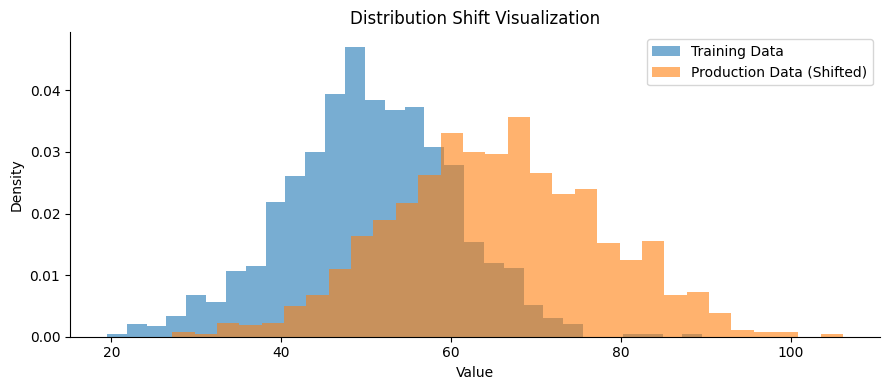

In [98]:
def compute_psi(expected, actual, bins=10):
    """
    PSI = sum((actual_pct - expected_pct) * ln(actual_pct / expected_pct))
    Add epsilon=1e-10 to avoid log(0).
    """
    # Create bins for the distributions
    combined_data = np.concatenate([expected, actual])
    hist, bin_edges = np.histogram(combined_data, bins=bins)

    # Calculate counts in each bin for expected and actual distributions
    expected_counts, _ = np.histogram(expected, bins=bin_edges)
    actual_counts, _ = np.histogram(actual, bins=bin_edges)

    # Calculate percentages, adding a small epsilon to avoid division by zero
    epsilon = 1e-10
    expected_pct = (expected_counts / len(expected)) + epsilon
    actual_pct = (actual_counts / len(actual)) + epsilon

    # Calculate PSI for each bin and sum them up
    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi

np.random.seed(1)
train_dist = np.random.normal(50, 10, 1000)    # training distribution
drift_dist = np.random.normal(65, 12, 1000)    # shifted production distribution

psi_value = compute_psi(train_dist, drift_dist)
print(f"PSI: {psi_value:.4f}")
print(f"Shift severity: {'Major' if psi_value > 0.2 else 'Minor' if psi_value > 0.1 else 'Stable'}")

# Plot both distributions
fig, ax = plt.subplots()
ax.hist(train_dist, bins=30, alpha=0.6, label='Training Data', density=True)
ax.hist(drift_dist, bins=30, alpha=0.6, label='Production Data (Shifted)', density=True)
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend(); ax.set_title('Distribution Shift Visualization')
plt.tight_layout(); plt.show()

**Concept Drift vs Covariate Drift & PSI Thresholds (5.5):**

-**Concept Drift:** This happens when the pattern the model has learned changes over time. For example, if a model predicts fashion trends and bell-bottom jeans suddenly become popular again after many years, the model may not make accurate predictions until it learns the new trend.
- **Covariate drift:** This is when the *data you feed into your model* changes its pattern, but the underlying relationship (what you're trying to predict) might stay the same. For example, if your model predicts house prices based on size, and suddenly only much larger houses are being sold, the input data (house size) has drifted.
- **PSI < 0.1:** This means there's **no significant shift** in your data. Everything looks stable, keep calm and carry on!
- **PSI 0.1–0.2:** This indicates a **minor shift**. It's a yellow flag – something has changed a little, and it might be worth keeping an eye on it or doing a quick check.
- **PSI > 0.2:** This is a **major shift** and a red flag! The data has changed significantly, and your model might not be reliable anymore. It's time to investigate seriously.
- **Retraining trigger example:** If the PSI for a critical input feature (like `age` or `salary`) consistently goes above `0.2` for three consecutive days, it could trigger an automatic alert to retrain the model with the new data.

---
## Part 6 — Probability Theory

### 6.1 Core Concepts

A bag contains: 4 red, 3 blue, 3 green marbles.

1. Define the sample space and compute P(red), P(blue), P(green).
2. Two marbles drawn **without replacement**. Compute:
   - P(first=red, second=blue) — **joint probability**
   - P(second=blue | first=red) — **conditional probability**
3. Are the two draws **independent**? Show mathematically.

In [99]:
total = 10
red, blue, green = 4, 3, 3

p_red   = red / total
p_blue  = blue / total
p_green = green / total

# Joint: P(red first AND blue second)
# P(first=red) * P(second=blue | first=red)
p_red_then_blue = (red / total) * (blue / (total - 1))

# Conditional: P(blue second | red first)
p_blue_given_red = blue / (total - 1)

# Independence check: are P(B|A) == P(B) ?
# P(second=blue | first=red) == P(second=blue)
# P(blue second | red first) is p_blue_given_red
# P(second=blue) is p_blue
independent = (p_blue_given_red == p_blue)

print(f"P(red)={p_red:.3f}, P(blue)={p_blue:.3f}, P(green)={p_green:.3f}")
print(f"P(red,blue): {p_red_then_blue:.4f}")
print(f"P(blue|red): {p_blue_given_red:.4f}")
print(f"P(blue):     {p_blue:.4f}")
print(f"Independent? {independent}")

# Tests
assert abs(p_red - 0.4) < 1e-9
assert abs(p_blue - 0.3) < 1e-9
assert abs(p_green - 0.3) < 1e-9
assert abs(p_red_then_blue - (4/10 * 3/9)) < 1e-9
assert abs(p_blue_given_red - (3/9)) < 1e-9
assert independent == False
print("6.1 passed ✓")

P(red)=0.400, P(blue)=0.300, P(green)=0.300
P(red,blue): 0.1333
P(blue|red): 0.3333
P(blue):     0.3000
Independent? False
6.1 passed ✓


### 6.2 Distributions in the Wild

1. **Normal**: Plot N(μ=0, σ=1) and N(μ=2, σ=0.5) PDFs on the same axes.
2. **Binomial**: A coin is flipped 20 times. Plot the PMF for k=0..20 with p=0.5 and p=0.7.
3. **Poisson**: Average 3 customers/minute. Plot the PMF for k=0..15.
4. For each, write one real-world ML use case in comments.

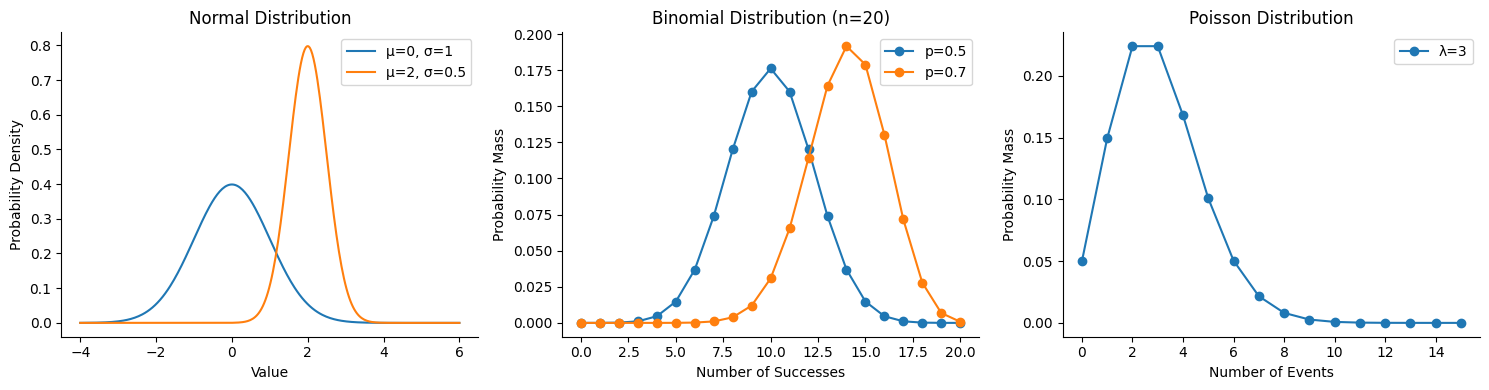

In [100]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Normal ──────────────────────────────────────────────────────────────────
x = np.linspace(-4, 6, 300)
# Plot N(μ=0, σ=1)
axes[0].plot(x, stats.norm.pdf(x, loc=0, scale=1), label='μ=0, σ=1')
# Plot N(μ=2, σ=0.5)
axes[0].plot(x, stats.norm.pdf(x, loc=2, scale=0.5), label='μ=2, σ=0.5')
axes[0].legend()
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Probability Density')
axes[0].set_title('Normal Distribution')
# ML use case: Modeling feature distributions (e.g., height, weight), assuming errors in regression models.

# ── Binomial ────────────────────────────────────────────────────────────────
k = np.arange(0, 21)
# Plot PMFs for p=0.5 and p=0.7 (n=20 flips)
axes[1].plot(k, stats.binom.pmf(k, n=20, p=0.5), 'o-', label='p=0.5')
axes[1].plot(k, stats.binom.pmf(k, n=20, p=0.7), 'o-', label='p=0.7')
axes[1].legend()
axes[1].set_xlabel('Number of Successes')
axes[1].set_ylabel('Probability Mass')
axes[1].set_title('Binomial Distribution (n=20)')
# ML use case: Predicting the number of successful trials (e.g., correct classifications in a batch, customer conversion rate).

# ── Poisson ─────────────────────────────────────────────────────────────────
k2 = np.arange(0, 16)
# Plot PMF (λ=3)
axes[2].plot(k2, stats.poisson.pmf(k2, mu=3), 'o-', label='λ=3')
axes[2].legend()
axes[2].set_xlabel('Number of Events')
axes[2].set_ylabel('Probability Mass')
axes[2].set_title('Poisson Distribution')
# ML use case: Modeling event counts over a fixed period (e.g., website visits per hour, defects per product).

plt.tight_layout(); plt.show()

### 6.3 Bayes' Theorem

**Scenario — Spam filter:**
- P(Spam) = 0.30 (prior)
- P("free" | Spam) = 0.80 (likelihood)
- P("free" | Not Spam) = 0.05

1. Compute P(Spam | "free") using Bayes' theorem.
2. Implement a simple `naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham)` that returns the posterior P(Spam | word).
3. In the markdown cell, map each term — **prior, likelihood, evidence, posterior** — to the spam example.

In [101]:
p_spam            = 0.30
p_free_given_spam = 0.80
p_free_given_ham  = 0.05
p_ham             = 1 - p_spam

# P(free) — law of total probability
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)

# Bayes
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print(f"P('free'): {p_free:.4f}")
print(f"P(Spam | 'free'): {p_spam_given_free:.4f}")

def naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham):
    # Calculate P(word) using the law of total probability
    p_word = (p_word_given_spam * prior_spam) + (p_word_given_ham * (1 - prior_spam))
    # Calculate P(Spam | word) using Bayes' Theorem
    posterior_spam = (p_word_given_spam * prior_spam) / p_word
    return posterior_spam

pred = naive_bayes_predict(0.30, 0.80, 0.05)
assert abs(pred - p_spam_given_free) < 1e-9
print(f"naive_bayes_predict: {pred:.4f}")
print("6.3 passed ✓")

P('free'): 0.2750
P(Spam | 'free'): 0.8727
naive_bayes_predict: 0.8727
6.3 passed ✓


**Bayes Term Mapping (6.3):**

| Term | Formula | In this example |
|------|---------|-----------------|
| Prior | P(Spam) | The overall chance that *any* incoming email is spam (0.30). |
| Likelihood | P(word \| Spam) | The chance of seeing the word "free" *if* the email is known to be spam (0.80). |
| Evidence | P(word) | The overall chance of seeing the word "free" in *any* email, spam or not. |
| Posterior | P(Spam \| word) | The updated chance that an email is spam, *after* we've seen it contains the word "free". |

### 6.4 Central Limit Theorem

1. Define a population following an **exponential distribution** (λ=1, size=100,000).
2. Repeatedly draw samples of size `n=30` and record their means — do this 5,000 times.
3. Plot the histogram of sample means.
4. Overlay the **theoretical normal distribution** predicted by the CLT: μ = population mean, σ = population_std / sqrt(n).
5. Run a KS test to confirm the distribution of sample means is approximately normal.

Population mean: 0.9997, Population std: 1.0026
Sample means mean: 0.9966, std: 0.1814
CLT predicted std: 0.1830


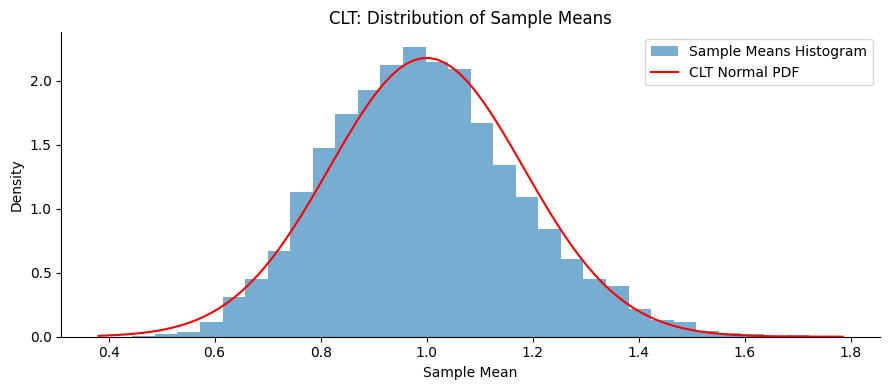

KS test p-value: 0.0001 → Approximately normal? False


In [102]:
np.random.seed(0) # Changed seed from 7 to 0
population = np.random.exponential(scale=1.0, size=100_000)

n_samples = 5000
sample_size = 30
# Repeatedly draw samples of size n=30 and record their means
sample_means = np.array([np.random.choice(population, size=sample_size, replace=True).mean() for _ in range(n_samples)])

pop_mean = population.mean()
pop_std  = population.std()
# Predicted standard deviation of sample means by CLT
clt_std  = pop_std / np.sqrt(sample_size)

print(f"Population mean: {pop_mean:.4f}, Population std: {pop_std:.4f}")
print(f"Sample means mean: {sample_means.mean():.4f}, std: {sample_means.std():.4f}")
print(f"CLT predicted std: {clt_std:.4f}")

# Plot
fig, ax = plt.subplots()
# Histogram of sample means
ax.hist(sample_means, bins=30, density=True, alpha=0.6, label='Sample Means Histogram')

# Overlay theoretical normal distribution
x_clt = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)
ax.plot(x_clt, stats.norm.pdf(x_clt, loc=pop_mean, scale=clt_std), color='red', label='CLT Normal PDF')

ax.legend()
ax.set_xlabel('Sample Mean')
ax.set_ylabel('Density')
ax.set_title('CLT: Distribution of Sample Means')
plt.tight_layout(); plt.show()

# KS test to confirm approximate normality
ks_result = stats.kstest(sample_means, 'norm', args=(pop_mean, clt_std))
print(f"KS test p-value: {ks_result.pvalue:.4f} → Approximately normal? {ks_result.pvalue > 0.05}")

**CLT Reflection (6.4):**

The Central Limit Theorem is crucial because it states that the distribution of sample means will be approximately normal, regardless of the original population's distribution, as long as the sample size is large enough. This is fundamental for statistical inference, as it justifies using normal-based statistical tests (like t-tests) and confidence intervals, even when dealing with non-normally distributed data. In machine learning, it often underlies assumptions about error distributions and helps validate model performance metrics.

---
## 🏁 Submission Checklist

Before submitting, verify:

- [ ] All `assert` blocks pass without errors
- [ ] All `# YOUR CODE HERE` cells are filled
- [ ] All markdown reflection cells are filled in your own words
- [ ] All plots render with labels and titles
- [ ] Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)

**Save as:** `week1_<your_name>.ipynb`